In [2]:
#  Data Loading and Understanding
import pandas as pd
import numpy as np 
import warnings
warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [3]:
df1=pd.read_excel("../data/raw/online_retail_II.xlsx", sheet_name="Year 2009-2010")
df2=pd.read_excel("../data/raw/online_retail_II.xlsx", sheet_name="Year 2010-2011")

df=pd.concat([df1,df2], ignore_index=True)

print("Sheet 1 rows: ",len(df1))
print("Sheet 2 rows: ",len(df2))
print("Combined rows: ",len(df))
print("Columns: ",list(df.columns))
      
      
      
      
      
      
      
      
      
      

Sheet 1 rows:  525461
Sheet 2 rows:  541910
Combined rows:  1067371
Columns:  ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [4]:
#see first 5 rows of dataset
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
#shape of dataset
print("Rows and Columns:",df.shape)
print()

#data types of each column
print("Data Types: ")
print(df.dtypes)

Rows and Columns: (1067371, 8)

Data Types: 
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [6]:
#check for missing values
print("Missing Values: ")
print(df.isnull().sum())
print()

#missing percentage
print("Missing Percentage: ")
print(round(df.isnull().sum()/len(df)*100,2))

Missing Values: 
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Missing Percentage: 
Invoice         0.00
StockCode       0.00
Description     0.41
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    22.77
Country         0.00
dtype: float64


In [7]:
#check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 34335


In [8]:
#check cancelled orders
cancelled=df[df['Invoice'].astype(str).str.startswith('C')]
print("Cancelled Orders: ", len(cancelled))
print("Sample Cancelled Orders: ")
cancelled.head(3)

Cancelled Orders:  19494
Sample Cancelled Orders: 


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia


In [9]:
#check negative quantity rows
print("Negative Quantity rows:",len(df[df['Quantity']<=0]))

#check zero or negative price rows
print("Zero or Negative Price rows:",len(df[df['Price']<=0]))

Negative Quantity rows: 22950
Zero or Negative Price rows: 6207


In [10]:
# Start cleaning
df_clean = df.copy()
print("Original rows:", len(df_clean))

# Step 1 - Remove missing Customer IDs
df_clean = df_clean.dropna(subset=['Customer ID'])
print("After removing missing Customer ID:", len(df_clean))

# Step 2 - Remove duplicate rows
df_clean = df_clean.drop_duplicates()
print("After removing duplicates:", len(df_clean))

# Step 3 - Remove cancelled orders
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print("After removing cancellations:", len(df_clean))

# Step 4 - Remove negative quantity
df_clean = df_clean[df_clean['Quantity'] > 0]
print("After removing negative quantity:", len(df_clean))

# Step 5 - Remove zero or negative price
df_clean = df_clean[df_clean['Price'] > 0]
print("After removing bad prices:", len(df_clean))

print()
print("Total rows removed:", len(df) - len(df_clean))
print("Clean dataset rows:", len(df_clean))

Original rows: 1067371
After removing missing Customer ID: 824364
After removing duplicates: 797885
After removing cancellations: 779495
After removing negative quantity: 779495
After removing bad prices: 779425

Total rows removed: 287946
Clean dataset rows: 779425


In [11]:
# fix data types

#fix Customer ID to be string and remove decimal places
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int).astype(str)

#rename columns - remove space for easier coding 
df_clean = df_clean.rename(columns={'Customer ID':'CustomerID'})

#verify
print("Customer ID sample:", df_clean['CustomerID'].head().tolist())
print("Customer ID data type:", df_clean['CustomerID'].dtype)
print()
print("Updated Columns:", list(df_clean.columns))



Customer ID sample: ['13085', '13085', '13085', '13085', '13085']
Customer ID data type: object

Updated Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


In [12]:
#final check for clean data
print("Shape:", df_clean.shape)
print()
print("Missing values:")
print(df_clean.isnull().sum())
print()
print("Data types:")
print(df_clean.dtypes)
print()
print("Date range:")
print("From:", df_clean['InvoiceDate'].min())
print("To:  ", df_clean['InvoiceDate'].max())
print()
print("Unique customers:", df_clean['CustomerID'].nunique())
print("Unique products: ", df_clean['StockCode'].nunique())
print("Unique countries:", df_clean['Country'].nunique())

Shape: (779425, 8)

Missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
dtype: int64

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
CustomerID             object
Country                object
dtype: object

Date range:
From: 2009-12-01 07:45:00
To:   2011-12-09 12:50:00

Unique customers: 5878
Unique products:  4631
Unique countries: 41


In [13]:
#saving clean data 
df_clean.to_csv("../data/processed/online_retail_clean.csv", index=False)

print("Clean data saved successfully!")
print("Location: data/processed/online_retail_clean.csv")
print("Rows saved:", len(df_clean))

Clean data saved successfully!
Location: data/processed/online_retail_clean.csv
Rows saved: 779425


In [14]:
#starting feature engineering
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load clean data
df = pd.read_csv("../data/processed/online_retail_clean.csv")

# Fix date column - CSV doesn't remember datetime type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Data loaded successfully!")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Data loaded successfully!
Shape: (779425, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


In [15]:
#Creating total revenue
df['TotalRevenue'] = df['Quantity'] * df['Price']

print("TotalRevenue column created!")
print()
print("Sample:")
print(df[['Invoice', 'Quantity', 'Price', 'TotalRevenue']].head())
print()
print("Total revenue across all transactions: £", round(df['TotalRevenue'].sum(), 2))

TotalRevenue column created!

Sample:
   Invoice  Quantity  Price  TotalRevenue
0   489434        12   6.95          83.4
1   489434        12   6.75          81.0
2   489434        12   6.75          81.0
3   489434        48   2.10         100.8
4   489434        24   1.25          30.0

Total revenue across all transactions: £ 17374804.27


In [16]:
#Extract Date Features
# Extract useful features from InvoiceDate
df['Year']       = df['InvoiceDate'].dt.year
df['Month']      = df['InvoiceDate'].dt.month
df['Day']        = df['InvoiceDate'].dt.day
df['Hour']       = df['InvoiceDate'].dt.hour
df['DayOfWeek']  = df['InvoiceDate'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Quarter']    = df['InvoiceDate'].dt.quarter
df['IsWeekend']  = (df['InvoiceDate'].dt.dayofweek >= 5).astype(int)

print("Date features created!")
print()
print("Sample:")
print(df[['InvoiceDate', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'Quarter', 'IsWeekend']].head())

Date features created!

Sample:
          InvoiceDate  Year  Month  Day  Hour  DayOfWeek  Quarter  IsWeekend
0 2009-12-01 07:45:00  2009     12    1     7          1        4          0
1 2009-12-01 07:45:00  2009     12    1     7          1        4          0
2 2009-12-01 07:45:00  2009     12    1     7          1        4          0
3 2009-12-01 07:45:00  2009     12    1     7          1        4          0
4 2009-12-01 07:45:00  2009     12    1     7          1        4          0


In [17]:
#Create RFM features
#Reference date - 1 day after last transaction in dataset
# Reference date - 1 day after last transaction in dataset
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

# Calculate RFM per customer
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalRevenue', 'sum')
).reset_index()

print("\nRFM Table created!")
print("Total customers:", len(rfm))
print()
print("Sample:")
print(rfm.head())

Reference date: 2011-12-10 12:50:00

RFM Table created!
Total customers: 5878

Sample:
   CustomerID  Recency  Frequency  Monetary
0       12346      326         12  77556.46
1       12347        2          8   4921.53
2       12348       75          5   2019.40
3       12349       19          4   4428.69
4       12350      310          1    334.40


In [18]:
#creating churn labels
# Label customers as churned or not
# Definition: no purchase in last 90 days = churned

rfm['Churned'] = (rfm['Recency'] > 90).astype(int)

print("Churn label created!")
print()
print("Active customers (not churned):", len(rfm[rfm['Churned'] == 0]))
print("Churned customers:", len(rfm[rfm['Churned'] == 1]))
print()
print("Churn rate:", round(rfm['Churned'].mean() * 100, 2), "%")

Churn label created!

Active customers (not churned): 2889
Churned customers: 2989

Churn rate: 50.85 %


In [19]:
# Create daily sales time series:
# Aggregate daily sales - needed for demand forecasting
daily_sales = df.groupby(df['InvoiceDate'].dt.date).agg(
    Revenue      = ('TotalRevenue', 'sum'),
    Orders       = ('Invoice', 'nunique'),
    Quantity     = ('Quantity', 'sum')
).reset_index()

daily_sales.columns = ['Date', 'Revenue', 'Orders', 'Quantity']
daily_sales = daily_sales.sort_values('Date').reset_index(drop=True)

print("Daily sales time series created!")
print("Total days:", len(daily_sales))
print()
print("Sample:")
print(daily_sales.head())

Daily sales time series created!
Total days: 604

Sample:
         Date   Revenue  Orders  Quantity
0  2009-12-01  43894.87      98     24335
1  2009-12-02  52762.06     110     29679
2  2009-12-03  67413.62     122     48009
3  2009-12-04  33913.81      80     19954
4  2009-12-05   9803.05      30      5119


In [20]:
#Save all feature files:
# Save RFM features
rfm.to_csv("../data/features/rfm_features.csv", index=False)

# Save daily sales
daily_sales.to_csv("../data/features/daily_sales.csv", index=False)

# Save final engineered dataset
df.to_csv("../data/processed/online_retail_featured.csv", index=False)

print("All files saved successfully!")
print()
print("Files created:")
print("  data/features/rfm_features.csv        →", len(rfm), "customers")
print("  data/features/daily_sales.csv         →", len(daily_sales), "days")
print("  data/processed/online_retail_featured.csv →", len(df), "rows")

All files saved successfully!

Files created:
  data/features/rfm_features.csv        → 5878 customers
  data/features/daily_sales.csv         → 604 days
  data/processed/online_retail_featured.csv → 779425 rows


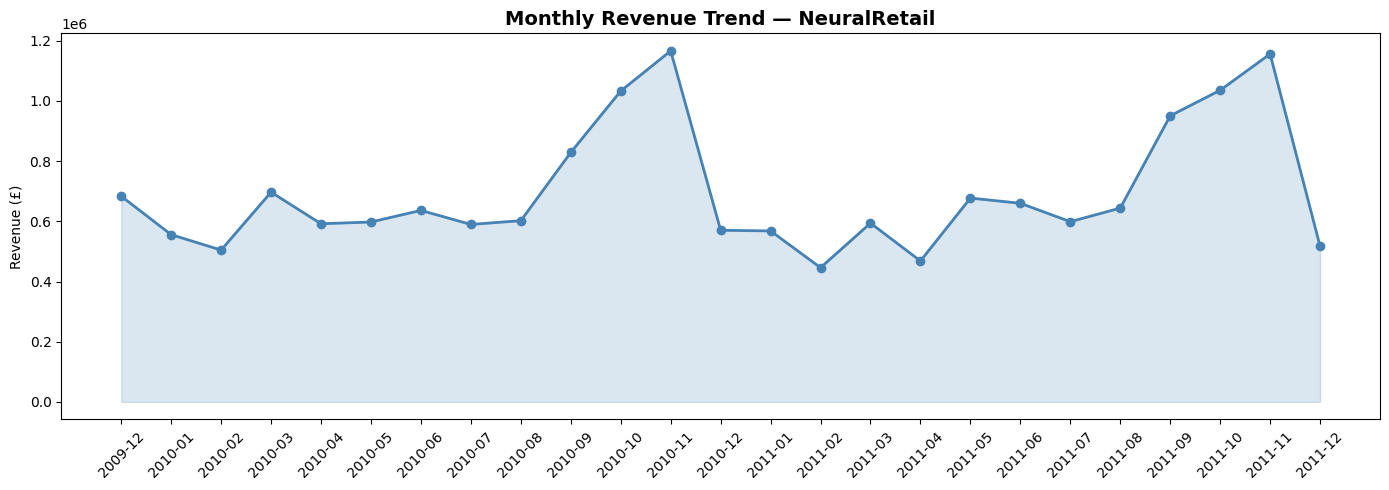

Plot saved!


In [21]:
#EDA Plot 1: Monthly Revenue:
import matplotlib.pyplot as plt
import seaborn as sns

# Monthly revenue trend
monthly = df.groupby(['Year', 'Month'])['TotalRevenue'].sum().reset_index()
monthly['YearMonth'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(monthly['YearMonth'], monthly['TotalRevenue'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(monthly)), monthly['TotalRevenue'], alpha=0.2, color='steelblue')
plt.xticks(range(len(monthly)), monthly['YearMonth'], rotation=45)
plt.title('Monthly Revenue Trend — NeuralRetail', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/plots/monthly_revenue.png', dpi=150)
plt.show()
print("Plot saved!")

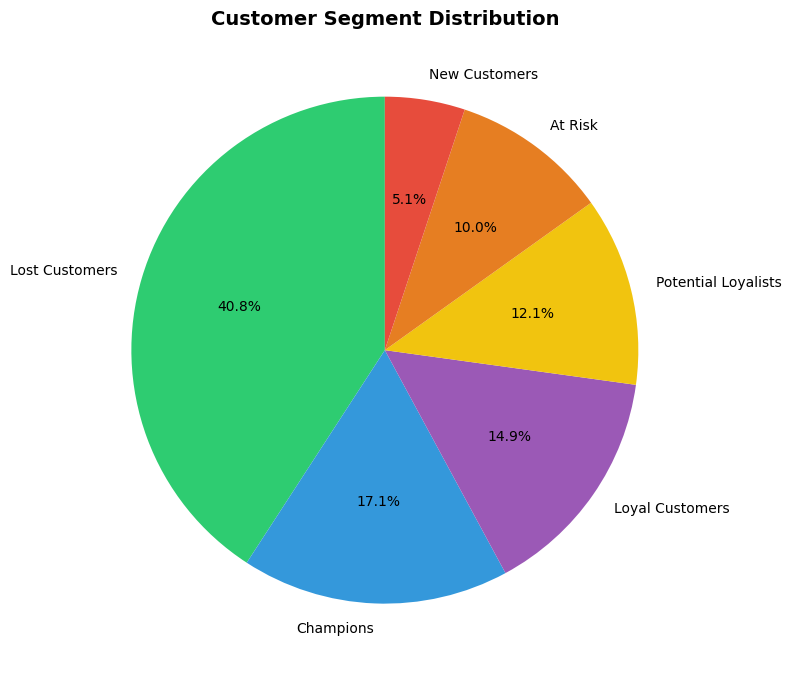

Segments:
Segment
Lost Customers         2400
Champions              1003
Loyal Customers         877
Potential Loyalists     709
At Risk                 589
New Customers           300
Name: count, dtype: int64


In [22]:
#EDA Plot 2: Customer Segments:
# Segment customers based on RFM total score
def segment(row):
    if row['Recency'] <= 30 and row['Frequency'] >= 5 and row['Monetary'] >= 1000:
        return 'Champions'
    elif row['Recency'] <= 60 and row['Frequency'] >= 3:
        return 'Loyal Customers'
    elif row['Recency'] <= 30:
        return 'New Customers'
    elif row['Recency'] <= 90:
        return 'Potential Loyalists'
    elif row['Recency'] <= 180:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment, axis=1)

# Plot
seg_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#9b59b6','#f1c40f','#e67e22','#e74c3c']

plt.figure(figsize=(8, 8))
plt.pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/plots/customer_segments.png', dpi=150)
plt.show()
print("Segments:")
print(seg_counts)

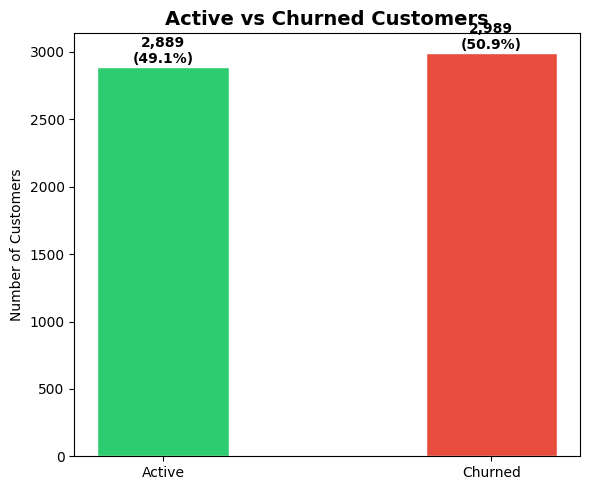

Plot saved!


In [23]:
# EDA Plot 3: Churn Distribution:
# Churn bar chart
plt.figure(figsize=(6, 5))
labels = ['Active', 'Churned']
values = [len(rfm[rfm['Churned']==0]), len(rfm[rfm['Churned']==1])]
colors = ['#2ecc71', '#e74c3c']

bars = plt.bar(labels, values, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(rfm)*100:.1f}%)',
             ha='center', fontweight='bold')

plt.title('Active vs Churned Customers', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../reports/plots/churn_distribution.png', dpi=150)
plt.show()
print("Plot saved!")

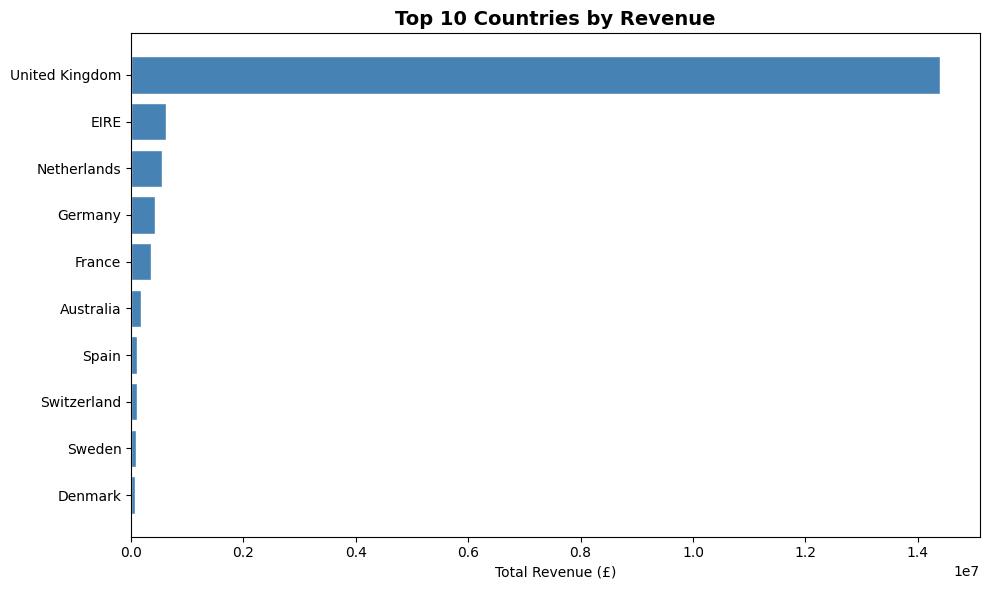

Plot saved!


In [24]:
#EDA Plot 4: Top 10 Countries:
# Top 10 countries by revenue
top_countries = df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_countries.index, top_countries.values, color='steelblue', edgecolor='white')
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/plots/top_countries.png', dpi=150)
plt.show()
print("Plot saved!")


In [ ]:
#Summary Of Week 1 task:
print("=" * 50)
print("   WEEK 1 COMPLETE — NEURALRETAIL")
print("=" * 50)
print()
print("DATASET")
print(f"  Raw rows:          1,067,371")
print(f"  Clean rows:        {len(df):,}")
print(f"  Rows removed:      {1067371 - len(df):,}")
print()
print("CUSTOMERS")
print(f"  Total customers:   {len(rfm):,}")
print(f"  Active:            {len(rfm[rfm['Churned']==0]):,}")
print(f"  Churned:           {len(rfm[rfm['Churned']==1]):,}")
print(f"  Churn rate:        {round(rfm['Churned'].mean()*100,2)}%")
print()
print("REVENUE")
print(f"  Total revenue:     £{df['TotalRevenue'].sum():,.2f}")
print(f"  Avg order value:   £{df.groupby('Invoice')['TotalRevenue'].sum().mean():,.2f}")
print()
print("TIME SERIES")
print(f"  Date range:        {daily_sales['Date'].min()} → {daily_sales['Date'].max()}")
print(f"  Total days:        {len(daily_sales)}")
print()
print("FILES SAVED")
print("  data/processed/online_retail_clean.csv")
print("  data/processed/online_retail_featured.csv")
print("  data/features/rfm_features.csv")
print("  data/features/daily_sales.csv")
print("  reports/plots/monthly_revenue.png")
print("  reports/plots/customer_segments.png")
print("  reports/plots/churn_distribution.png")
print("  reports/plots/top_countries.png")
print()
print("READY FOR WEEK 2:")
print("  → Customer Segmentation (KMeans)")
print("  → Demand Forecasting (Prophet/LSTM)")
print("  → Churn Prediction (XGBoost)")
print("  → Inventory Optimization")
print("=" * 50)

   WEEK 1 COMPLETE — NEURALRETAIL

DATASET
  Raw rows:          1,067,371
  Clean rows:        779,425
  Rows removed:      287,946

CUSTOMERS
  Total customers:   5,878
  Active:            2,889
  Churned:           2,989
  Churn rate:        50.85%

REVENUE
  Total revenue:     £17,374,804.27
  Avg order value:   £469.98

TIME SERIES
  Date range:        2009-12-01 → 2011-12-09
  Total days:        604

FILES SAVED
  data/processed/online_retail_clean.csv
  data/processed/online_retail_featured.csv
  data/features/rfm_features.csv
  data/features/daily_sales.csv
  reports/plots/monthly_revenue.png
  reports/plots/customer_segments.png
  reports/plots/churn_distribution.png
  reports/plots/top_countries.png

READY FOR WEEK 2:
  → Customer Segmentation (KMeans)
  → Demand Forecasting (Prophet/LSTM)
  → Churn Prediction (XGBoost)
  → Inventory Optimization
